In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

In [54]:
def retreive_stock_data(ticker_list, start_date, end_date):
    data = yf.download(ticker_list, start_date, end_date)
    close_prices = data['Close']
    daily_returns = close_prices.pct_change()
    
    mean_returns = daily_returns.mean()
    covariance_matrix = daily_returns.cov()
    
    return mean_returns, covariance_matrix
    
    
    
    

In [56]:
# Create portfolio
tickers = ['HSBA.L', 'VOD.L', 'GSK.L', 'MKS.L', 'BARC.L']
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=300)



In [58]:
mean_returns, cov_matrix = fetch_stock_data(tickers, start_date, end_date)
print("Mean Daily Returns:")
print(mean_returns)

/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/ipykernel_1507/3636533024.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_list, start_date, end_date)
[*********************100%***********************]  5 of 5 completed

Mean Daily Returns:
Ticker
BARC.L    0.001957
GSK.L     0.000642
HSBA.L    0.002352
MKS.L     0.000019
VOD.L     0.001821
dtype: float64



/var/folders/d_/w7lg5l0s3lgdmwvxxs5xwzb40000gn/T/ipykernel_1507/3636533024.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = close_prices.pct_change()


In [60]:
# Assign weights to stocks in portfolio
portfolio_weights = np.random.random(len(mean_returns))
portfolio_weights /= np.sum(portfolio_weights)
print("\nPortfolio Weights:")
print(portfolio_weights)





Portfolio Weights:
[0.35194262 0.05759731 0.13762493 0.12457851 0.32825662]


In [62]:
# Details of the simulation
num_simulations = 1000
days_ahead = 100
initial_capital = 1000


In [64]:
# Create mean returns matrix 
mean_matrix = np.full(shape=(days_ahead, len(portfolio_weights)), fill_value=mean_returns)
mean_matrix = mean_matrix.T  # Transpose to (stocks x days)

# Inital matrix
simulation_results = np.full(shape=(days_ahead, num_simulations), fill_value=0.0)


In [66]:
# Monte Carlo simulations
for sim in range(num_simulations):
    # Random noise
    random_noise = np.random.normal(size=(days_ahead, len(portfolio_weights)))
    
    # Cholesky decomposition to obtain correlation
    cholesky_matrix = np.linalg.cholesky(cov_matrix)
    
    # Correlated daily returns
    simulated_returns = mean_matrix + np.inner(cholesky_matrix, random_noise)
    
    # Calculate portfolio value
    simulation_results[:, sim] = np.cumprod(
        np.inner(portfolio_weights, simulated_returns.T) + 1
    ) * initial_capital



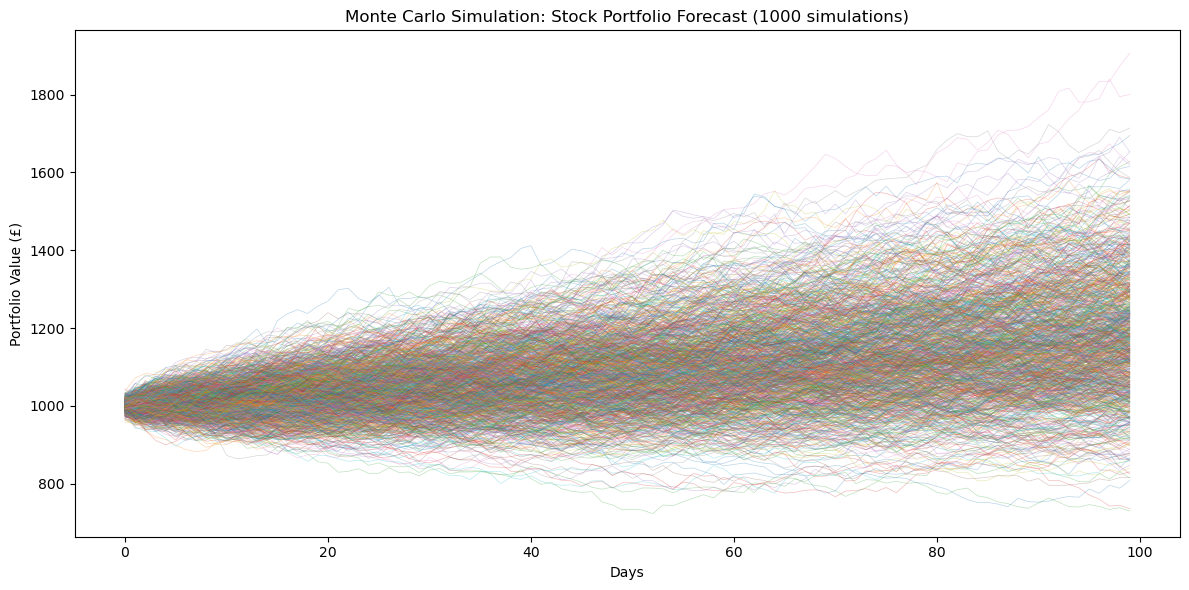

In [68]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(simulation_results, alpha=0.3, linewidth=0.5)
plt.ylabel('Portfolio Value (£)')
plt.xlabel('Days')
plt.title('Monte Carlo Simulation: Stock Portfolio Forecast (1000 simulations)')
plt.tight_layout()
plt.show()